In [1]:
import sys
import numpy as np
import scipy
import matplotlib
import sklearn

import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA

print(sys.executable)
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)

/opt/miniconda3/envs/aggression_py/bin/python
numpy: 2.4.3
sklearn: 1.8.0


In [2]:
from pathlib import Path

data_dir = Path("/Users/amadeus/Documents/MATLAB/ephysExercise/")

N = sio.loadmat(data_dir / "neuralData.mat", squeeze_me=True, struct_as_record=False)
P = sio.loadmat(data_dir / "peripheralData.mat", squeeze_me=True, struct_as_record=False)
B = sio.loadmat(data_dir / "behaviorData.mat", squeeze_me=True, struct_as_record=False)

FR = N["FR"]
peripheralData = P["peripheralData"]
behaviorData = B["behaviorData"]

print("FR shape:", FR.shape)
print("peripheralData type:", type(peripheralData))
print("behaviorData type:", type(behaviorData))

FR shape: (218, 60000)
peripheralData type: <class 'numpy.ndarray'>
behaviorData type: <class 'numpy.ndarray'>


In [3]:
def cell_to_dict(cell_array):
    """
    Convert MATLAB-style cell array of {name, vector} rows into a Python dict.
    """
    out = {}
    arr = np.array(cell_array, dtype=object)

    if arr.ndim == 1:
        rows = arr
    else:
        rows = arr

    for row in rows:
        row = np.array(row, dtype=object).ravel()
        if len(row) < 2:
            continue
        name = str(row[0])
        vec = np.asarray(row[1]).astype(float).ravel()
        out[name] = vec
    return out

periph = cell_to_dict(peripheralData)
behav = cell_to_dict(behaviorData)

print("Peripheral keys:", list(periph.keys()))
print("Behavior keys:", list(behav.keys()))

Peripheral keys: ['gateOpen', 'whiteLight', 'ctBudSniff', 'lickEmpty', 'lickMilk']
Behavior keys: ['attackOfIntLeft', 'attackOfIntRight', 'chaseOfIntLeft', 'chaseOfIntRight', 'submissionSignFromIntLeft', 'submissionSignFromIntRight', 'attackDark']


In [4]:
fs = 50.0
n_neurons, nT = FR.shape
t_sec = np.arange(nT) / fs
t_min = t_sec / 60.0

print(f"n_neurons = {n_neurons}, n_timebins = {nT}, duration(min) = {t_min[-1]:.2f}")

for k, v in periph.items():
    print(f"periph[{k}] length = {len(v)}")

for k, v in behav.items():
    print(f"behav[{k}] length = {len(v)}")

for k, v in periph.items():
    assert len(v) == nT, f"Peripheral channel {k} length mismatch: {len(v)} vs {nT}"

for k, v in behav.items():
    assert len(v) == nT, f"Behavior channel {k} length mismatch: {len(v)} vs {nT}"

n_neurons = 218, n_timebins = 60000, duration(min) = 20.00
periph[gateOpen] length = 60000
periph[whiteLight] length = 60000
periph[ctBudSniff] length = 60000
periph[lickEmpty] length = 60000
periph[lickMilk] length = 60000
behav[attackOfIntLeft] length = 60000
behav[attackOfIntRight] length = 60000
behav[chaseOfIntLeft] length = 60000
behav[chaseOfIntRight] length = 60000
behav[submissionSignFromIntLeft] length = 60000
behav[submissionSignFromIntRight] length = 60000
behav[attackDark] length = 60000


In [5]:
# The same as loadingScript.m
attack = (
    behav["attackOfIntLeft"].astype(bool)
    | behav["attackOfIntRight"].astype(bool)
    | behav["attackDark"].astype(bool)
)

submission = (
    behav["submissionSignFromIntLeft"].astype(bool)
    | behav["submissionSignFromIntRight"].astype(bool)
)

chase = (
    behav["chaseOfIntLeft"].astype(bool)
    | behav["chaseOfIntRight"].astype(bool)
)

# -------- peripheral summary --------
white_light = periph["whiteLight"].astype(bool)
red_light = ~white_light
gate_open = periph["gateOpen"].astype(bool)

sniff_urine = periph["ctBudSniff"].astype(bool)
lick_milk = periph["lickMilk"].astype(bool)
lick_empty = periph["lickEmpty"].astype(bool)

In [ ]:
def smooth_and_zscore_fr(FR, fs=50.0, smooth_width_ms=200.0):
    smoothWidth_bins = round((smooth_width_ms / 1000.0) * fs)  # = 10
    sigma_bins = smoothWidth_bins / 3                           # = 3.0，和MATLAB一致
    FR_smooth = gaussian_filter1d(FR.astype(float), sigma=sigma_bins,
                                  axis=1, mode="nearest")
    mu = FR_smooth.mean(axis=1, keepdims=True)
    sd = FR_smooth.std(axis=1,  keepdims=True)
    sd[sd == 0] = 1.0
    FRz = (FR_smooth - mu) / sd
    FRz[~np.isfinite(FRz)] = 0.0
    return FR_smooth, FRz

FR_smooth, FRz  = smooth_and_zscore_fr(FR, fs=fs, smooth_width_ms=200)

print("FRz shape:", FRz.shape)

FRz shape: (218, 60000)


In [7]:
def first_true_idx(x):
    idx = np.flatnonzero(x)
    return idx[0] if len(idx) > 0 else None

def last_true_idx(x):
    idx = np.flatnonzero(x)
    return idx[-1] if len(idx) > 0 else None

# -----------------------------
# Basic transition indices
# -----------------------------
gate_start = first_true_idx(gate_open)
gate_end = last_true_idx(gate_open)

white_start_raw = first_true_idx(white_light)
white_end_raw = last_true_idx(white_light)

red_start_raw = first_true_idx(red_light)
red_end_raw = last_true_idx(red_light)

print("gate_start (min):", gate_start / fs / 60 if gate_start is not None else None)
print("gate_end   (min):", gate_end / fs / 60 if gate_end is not None else None)
print("white_start_raw (min):", white_start_raw / fs / 60 if white_start_raw is not None else None)
print("white_end_raw   (min):", white_end_raw / fs / 60 if white_end_raw is not None else None)
print("red_start_raw   (min):", red_start_raw / fs / 60 if red_start_raw is not None else None)
print("red_end_raw     (min):", red_end_raw / fs / 60 if red_end_raw is not None else None)

if gate_start is None:
    raise ValueError("gateOpen never becomes 1; cannot define phases.")

# -----------------------------
# Define phases by paradigm:
#   Pre       : before gate opens
#   WhiteAgg  : 5 min after gate opens
#   DarkAgg   : next 5 min
#   Post      : remainder
# -----------------------------
five_min_bins = int(5 * 60 * fs)

white_start = gate_start
white_end = min(white_start + five_min_bins - 1, nT - 1)

dark_start = white_end + 1
dark_end = min(dark_start + five_min_bins - 1, nT - 1)

phase_masks = {
    "Pre": np.zeros(nT, dtype=bool),
    "WhiteAgg": np.zeros(nT, dtype=bool),
    "DarkAgg": np.zeros(nT, dtype=bool),
    "Post": np.zeros(nT, dtype=bool),
}

phase_masks["Pre"][:white_start] = True
phase_masks["WhiteAgg"][white_start:white_end + 1] = True
phase_masks["DarkAgg"][dark_start:dark_end + 1] = True

if dark_end + 1 < nT:
    phase_masks["Post"][dark_end + 1:] = True

# -----------------------------
# Print summary
# -----------------------------
print("\nPhase summary:")
for name, mask in phase_masks.items():
    n_bins = mask.sum()
    print(
        f"{name:8s}: {n_bins:6d} bins | "
        f"{n_bins/fs:7.1f} s | "
        f"{n_bins/fs/60:5.2f} min"
    )

print("\nPhase boundaries (min):")
print("Pre      :", 0.0, "to", white_start / fs / 60)
print("WhiteAgg :", white_start / fs / 60, "to", white_end / fs / 60)
print("DarkAgg  :", dark_start / fs / 60, "to", dark_end / fs / 60)
print("Post     :", (dark_end + 1) / fs / 60 if dark_end + 1 < nT else None, "to", (nT - 1) / fs / 60)

gate_start (min): 5.756
gate_end   (min): 19.999666666666666
white_start_raw (min): 4.755
white_end_raw   (min): 10.760666666666667
red_start_raw   (min): 0.0
red_end_raw     (min): 19.999666666666666

Phase summary:
Pre     :  17268 bins |   345.4 s |  5.76 min
WhiteAgg:  15000 bins |   300.0 s |  5.00 min
DarkAgg :  15000 bins |   300.0 s |  5.00 min
Post    :  12732 bins |   254.6 s |  4.24 min

Phase boundaries (min):
Pre      : 0.0 to 5.756
WhiteAgg : 5.756 to 10.755666666666666
DarkAgg  : 10.756 to 15.755666666666666
Post     : 15.756 to 19.999666666666666


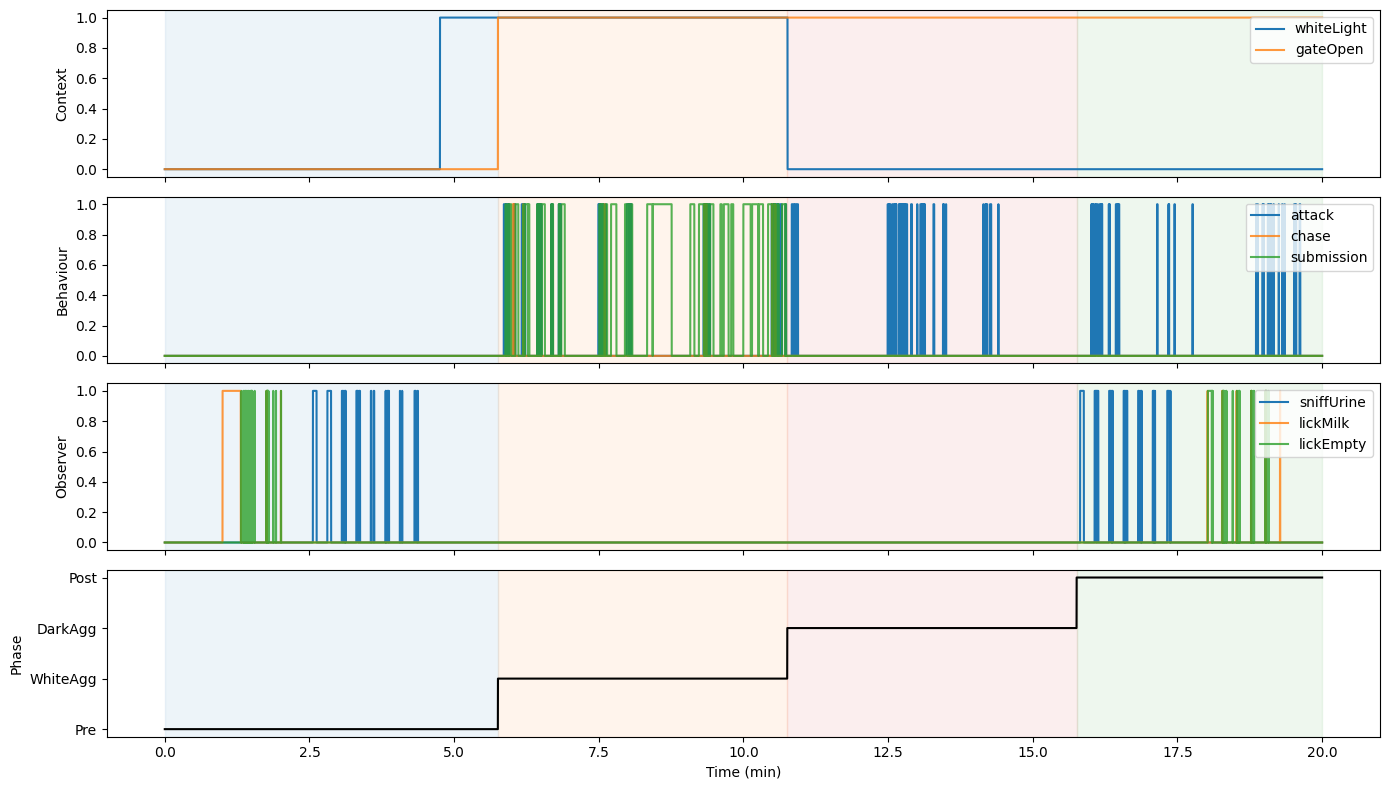

In [8]:
phase_names = ["Pre", "WhiteAgg", "DarkAgg", "Post"]
phase_colours = {
    "Pre": "tab:blue",
    "WhiteAgg": "tab:orange",
    "DarkAgg": "tab:red",
    "Post": "tab:green",
}

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

axes[0].plot(t_min, white_light.astype(float), label="whiteLight")
axes[0].plot(t_min, gate_open.astype(float), label="gateOpen", alpha=0.8)
axes[0].set_ylabel("Context")
axes[0].legend(loc="upper right")

axes[1].plot(t_min, attack.astype(float), label="attack")
axes[1].plot(t_min, chase.astype(float), label="chase", alpha=0.8)
axes[1].plot(t_min, submission.astype(float), label="submission", alpha=0.8)
axes[1].set_ylabel("Behaviour")
axes[1].legend(loc="upper right")

axes[2].plot(t_min, sniff_urine.astype(float), label="sniffUrine")
axes[2].plot(t_min, lick_milk.astype(float), label="lickMilk", alpha=0.8)
axes[2].plot(t_min, lick_empty.astype(float), label="lickEmpty", alpha=0.8)
axes[2].set_ylabel("Observer")
axes[2].legend(loc="upper right")

phase_map = np.full(nT, np.nan)
for i, name in enumerate(phase_names):
    phase_map[phase_masks[name]] = i

axes[3].plot(t_min, phase_map, color="k")
axes[3].set_yticks(range(len(phase_names)))
axes[3].set_yticklabels(phase_names)
axes[3].set_ylabel("Phase")
axes[3].set_xlabel("Time (min)")

for ax in axes:
    for name in phase_names:
        mask = phase_masks[name]
        idx = np.flatnonzero(mask)
        if len(idx) == 0:
            continue
        ax.axvspan(t_min[idx[0]], t_min[idx[-1]], alpha=0.08, color=phase_colours[name])

plt.tight_layout()
plt.show()

In [9]:
phase_vectors = {}

for name, mask in phase_masks.items():
    if mask.sum() == 0:
        continue
    phase_vectors[name] = FRz[:, mask].mean(axis=1)

for name, vec in phase_vectors.items():
    print(name, vec.shape, np.mean(vec), np.std(vec))

Pre (218,) -0.03747230056478862 0.4246424348882827
WhiteAgg (218,) 0.05176916372658142 0.23546581614778514
DarkAgg (218,) 0.06786072411230858 0.29708690535327775
Post (218,) -0.09011754880855656 0.41583383357947484


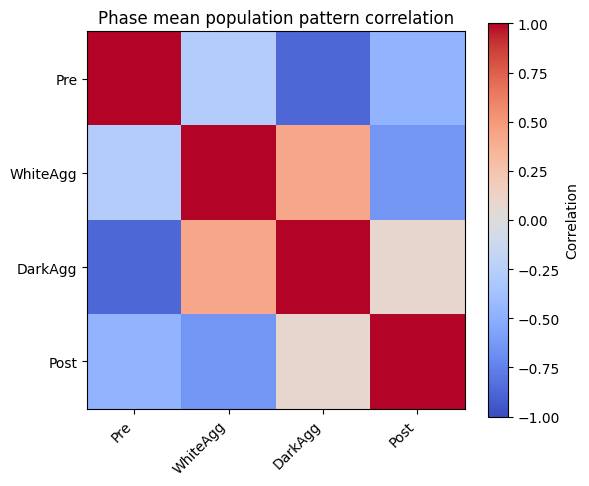

In [10]:
valid_phase_names = [name for name in phase_names if name in phase_vectors]
X_phase = np.stack([phase_vectors[name] for name in valid_phase_names], axis=0)  # phases x neurons

corr_mat = np.corrcoef(X_phase)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_mat, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(valid_phase_names)))
ax.set_yticks(range(len(valid_phase_names)))
ax.set_xticklabels(valid_phase_names, rotation=45, ha="right")
ax.set_yticklabels(valid_phase_names)
ax.set_title("Phase mean population pattern correlation")
plt.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

In [11]:
X = FRz.T  # time x neurons

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.09422308 0.06620559 0.0554654 ]


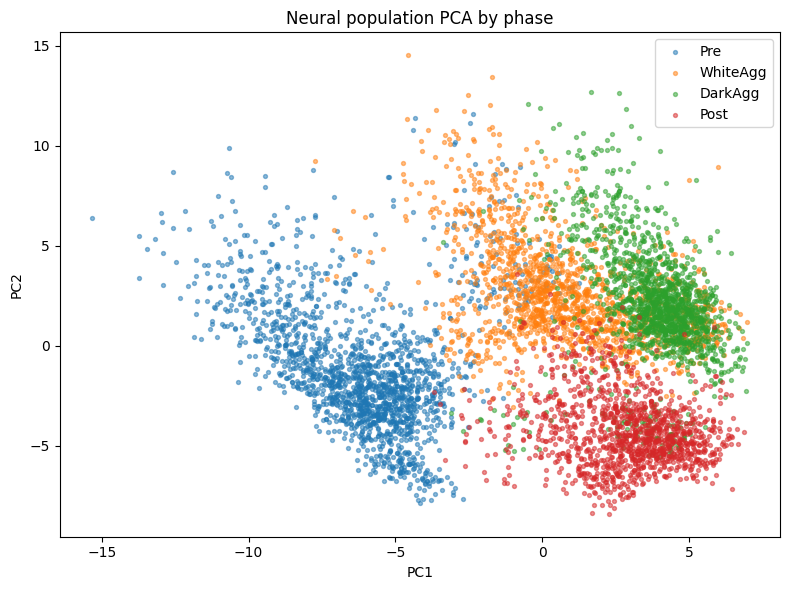

In [12]:
step = 10  # 每 10 个点取 1 个
idx_sub = np.arange(0, nT, step)

fig, ax = plt.subplots(figsize=(8, 6))

for name in phase_names:
    mask = phase_masks[name]
    mask_sub = mask[idx_sub]
    ax.scatter(
        X_pca[idx_sub[mask_sub], 0],
        X_pca[idx_sub[mask_sub], 1],
        s=8,
        alpha=0.5,
        label=name
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Neural population PCA by phase")
ax.legend()
plt.tight_layout()
plt.show()

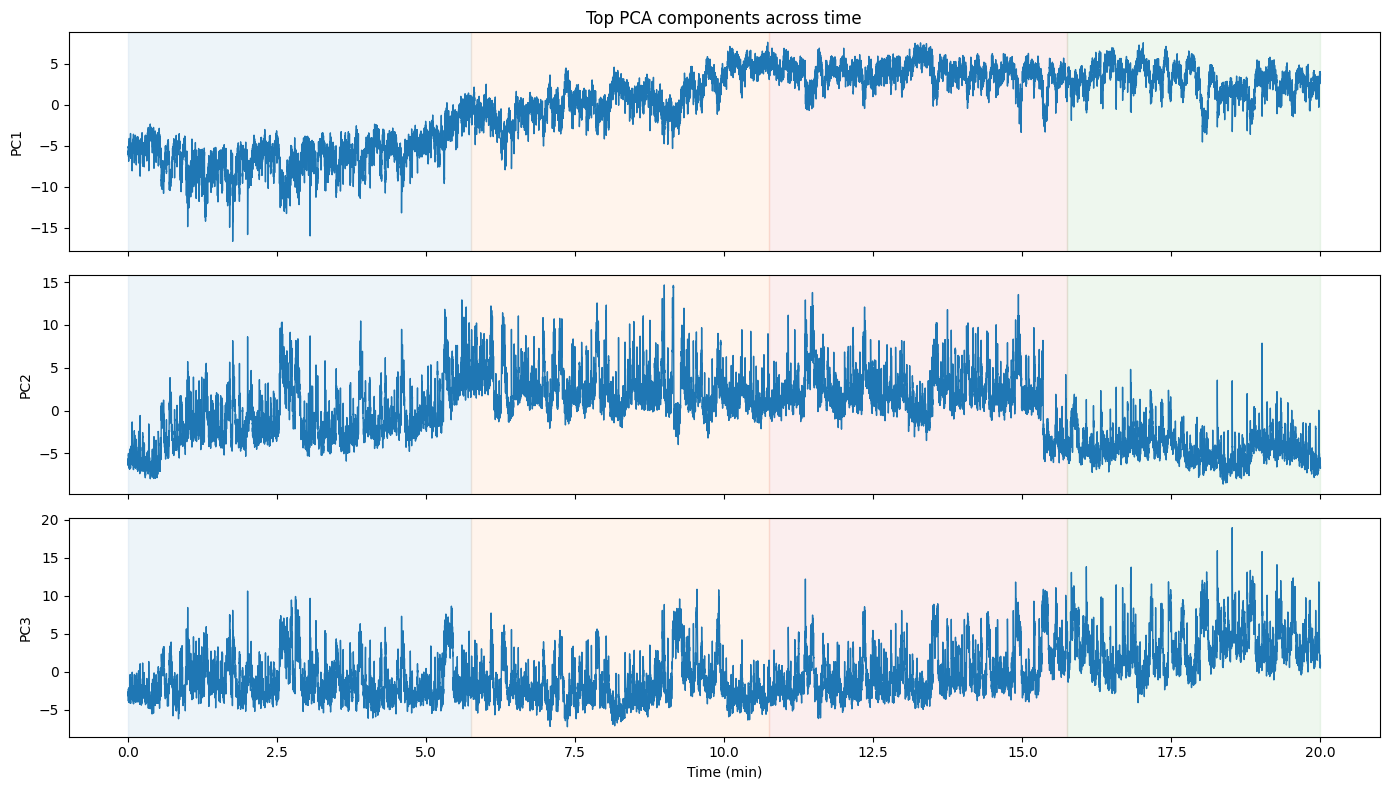

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for i in range(3):
    axes[i].plot(t_min, X_pca[:, i], lw=1)
    axes[i].set_ylabel(f"PC{i+1}")

    for name in phase_names:
        mask = phase_masks[name]
        idx = np.flatnonzero(mask)
        if len(idx) == 0:
            continue
        axes[i].axvspan(t_min[idx[0]], t_min[idx[-1]], alpha=0.08, color=phase_colours[name])

axes[-1].set_xlabel("Time (min)")
axes[0].set_title("Top PCA components across time")
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# Section 2 — Attack-aligned neural responses
# ============================================================

pre_sec = 2.0      # seconds before onset
post_sec = 4.0     # seconds after onset

pre_bins = int(pre_sec * fs)
post_bins = int(post_sec * fs)

print("pre_bins:", pre_bins, "post_bins:", post_bins)

pre_bins: 100 post_bins: 200


In [15]:
def get_onsets_from_binary_mask(mask):
    """
    Given a binary mask (1 during event), return onset indices of each event bout.
    """
    mask = np.asarray(mask).astype(bool)
    onset_mask = mask & (~np.roll(mask, 1))
    onset_mask[0] = mask[0]
    return np.flatnonzero(onset_mask)

# all attack onsets
attack_onsets_all = get_onsets_from_binary_mask(attack)

print("Total attack onsets:", len(attack_onsets_all))
print("First 10 onsets (bins):", attack_onsets_all[:10])
print("First 10 onsets (min):", attack_onsets_all[:10] / fs / 60)

Total attack onsets: 106
First 10 onsets (bins): [17573 17688 17701 17821 18095 18121 18500 18584 18650 19301]
First 10 onsets (min): [5.85766667 5.896      5.90033333 5.94033333 6.03166667 6.04033333
 6.16666667 6.19466667 6.21666667 6.43366667]


In [16]:
def filter_onsets_by_phase_and_window(onsets, phase_mask, nT, pre_bins, post_bins):
    """
    Keep only onsets that:
    1) fall within the given phase
    2) have a complete [onset-pre_bins, onset+post_bins] window inside recording
    """
    valid = []
    for o in onsets:
        if not phase_mask[o]:
            continue
        if (o - pre_bins) < 0:
            continue
        if (o + post_bins) >= nT:
            continue
        valid.append(o)
    return np.array(valid, dtype=int)

white_attack_onsets = filter_onsets_by_phase_and_window(
    attack_onsets_all, phase_masks["WhiteAgg"], nT, pre_bins, post_bins
)

dark_attack_onsets = filter_onsets_by_phase_and_window(
    attack_onsets_all, phase_masks["DarkAgg"], nT, pre_bins, post_bins
)

print("WhiteAgg attack onsets:", len(white_attack_onsets))
print("DarkAgg attack onsets :", len(dark_attack_onsets))

print("White attack onset times (min):", np.round(white_attack_onsets / fs / 60, 3))
print("Dark attack onset times (min):", np.round(dark_attack_onsets / fs / 60, 3))

WhiteAgg attack onsets: 38
DarkAgg attack onsets : 33
White attack onset times (min): [ 5.858  5.896  5.9    5.94   6.032  6.04   6.167  6.195  6.217  6.434
  6.455  6.467  6.474  6.501  6.678  6.686  6.807  6.832  7.492  7.511
  7.527  7.562  7.617  7.983  8.03   8.05   9.309  9.33   9.337  9.36
  9.409 10.487 10.498 10.531 10.552 10.589 10.635 10.724]
Dark attack onset times (min): [10.834 10.885 10.925 12.491 12.516 12.523 12.57  12.614 12.633 12.636
 12.688 12.693 12.724 12.747 12.77  12.776 12.784 12.813 12.895 13.001
 13.055 13.09  13.1   13.124 13.282 13.448 13.459 13.499 14.144 14.178
 14.192 14.259 14.404]


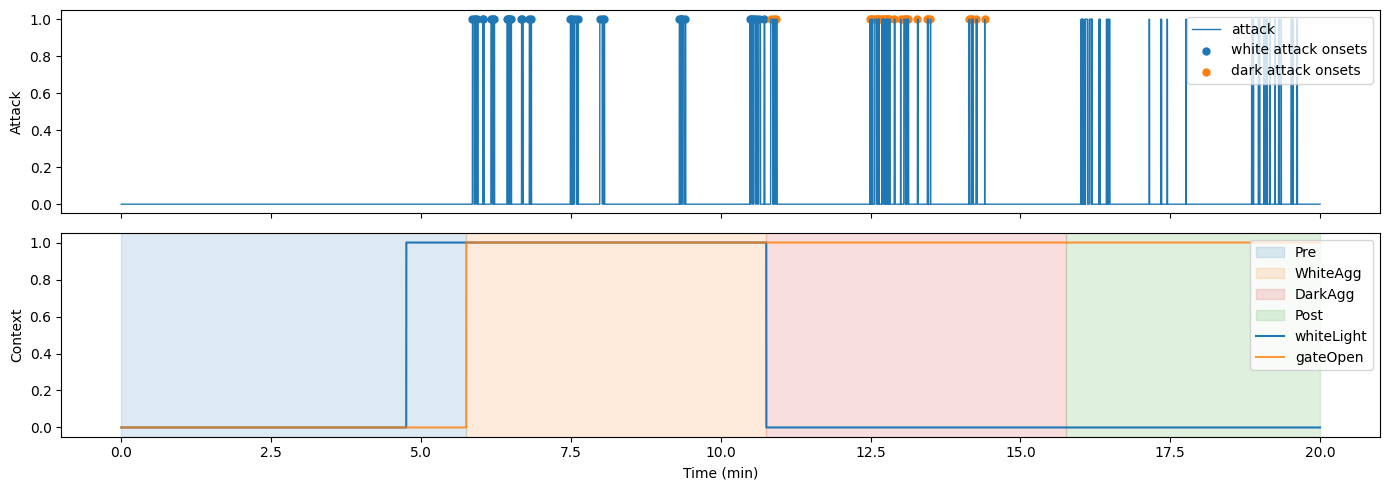

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

# attack mask
axes[0].plot(t_min, attack.astype(float), lw=1, label="attack")
axes[0].scatter(white_attack_onsets / fs / 60, np.ones_like(white_attack_onsets), s=25, label="white attack onsets")
axes[0].scatter(dark_attack_onsets / fs / 60, np.ones_like(dark_attack_onsets), s=25, label="dark attack onsets")
axes[0].set_ylabel("Attack")
axes[0].legend(loc="upper right")

# phases
phase_names_main = ["Pre", "WhiteAgg", "DarkAgg", "Post"]
phase_colours = {
    "Pre": "tab:blue",
    "WhiteAgg": "tab:orange",
    "DarkAgg": "tab:red",
    "Post": "tab:green",
}

for name in phase_names_main:
    idx = np.flatnonzero(phase_masks[name])
    if len(idx) > 0:
        axes[1].axvspan(t_min[idx[0]], t_min[idx[-1]], alpha=0.15, color=phase_colours[name], label=name)

axes[1].plot(t_min, white_light.astype(float), label="whiteLight")
axes[1].plot(t_min, gate_open.astype(float), label="gateOpen", alpha=0.8)
axes[1].set_ylabel("Context")
axes[1].set_xlabel("Time (min)")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

In [18]:
def extract_event_windows(FRz, onsets, pre_bins, post_bins):
    """
    Extract windows around each onset from FRz (neurons x time).
    Returns:
        windows: (n_events, n_neurons, n_window)
    """
    windows = []
    for o in onsets:
        w = FRz[:, o - pre_bins : o + post_bins + 1]
        windows.append(w)
    if len(windows) == 0:
        return np.empty((0, FRz.shape[0], pre_bins + post_bins + 1))
    return np.stack(windows, axis=0)

white_windows = extract_event_windows(FRz, white_attack_onsets, pre_bins, post_bins)
dark_windows = extract_event_windows(FRz, dark_attack_onsets, pre_bins, post_bins)

print("white_windows shape:", white_windows.shape)
print("dark_windows shape :", dark_windows.shape)

white_windows shape: (38, 218, 301)
dark_windows shape : (33, 218, 301)


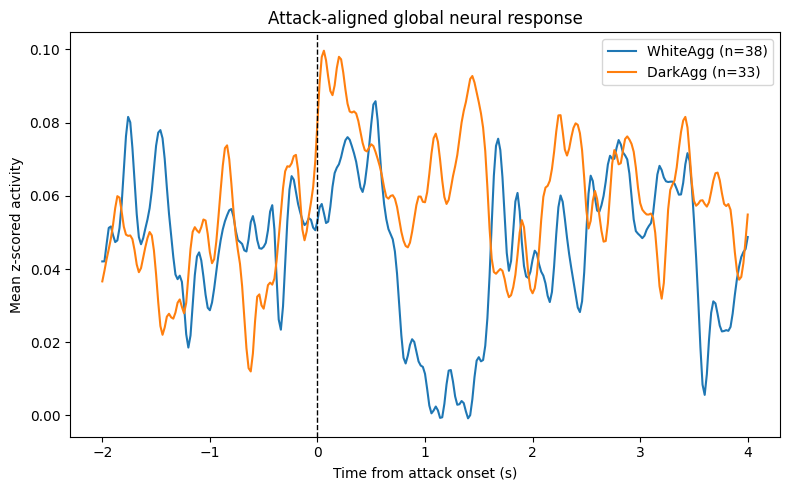

In [19]:
time_event = np.arange(-pre_bins, post_bins + 1) / fs

white_global = white_windows.mean(axis=1).mean(axis=0) if len(white_windows) > 0 else None
dark_global = dark_windows.mean(axis=1).mean(axis=0) if len(dark_windows) > 0 else None

fig, ax = plt.subplots(figsize=(8, 5))

if white_global is not None:
    ax.plot(time_event, white_global, label=f"WhiteAgg (n={len(white_windows)})")
if dark_global is not None:
    ax.plot(time_event, dark_global, label=f"DarkAgg (n={len(dark_windows)})")

ax.axvline(0, color="k", linestyle="--", lw=1)
ax.set_xlabel("Time from attack onset (s)")
ax.set_ylabel("Mean z-scored activity")
ax.set_title("Attack-aligned global neural response")
ax.legend()
plt.tight_layout()
plt.show()

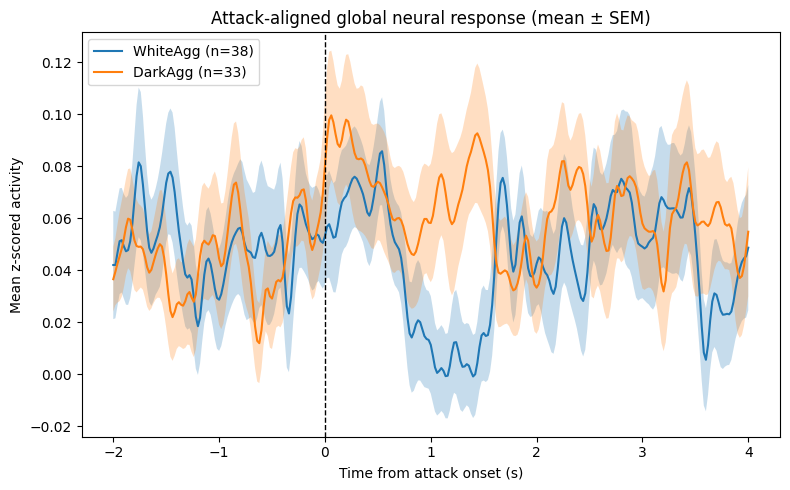

In [20]:
def mean_and_sem_over_events(windows):
    """
    windows: (n_events, n_neurons, n_time)
    First average over neurons within each event,
    then compute mean and SEM across events.
    """
    if len(windows) == 0:
        return None, None
    event_curves = windows.mean(axis=1)   # (n_events, n_time)
    mean_curve = event_curves.mean(axis=0)
    sem_curve = event_curves.std(axis=0, ddof=1) / np.sqrt(event_curves.shape[0]) if event_curves.shape[0] > 1 else np.zeros_like(mean_curve)
    return mean_curve, sem_curve

white_mean, white_sem = mean_and_sem_over_events(white_windows)
dark_mean, dark_sem = mean_and_sem_over_events(dark_windows)

fig, ax = plt.subplots(figsize=(8, 5))

if white_mean is not None:
    ax.plot(time_event, white_mean, label=f"WhiteAgg (n={len(white_windows)})")
    ax.fill_between(time_event, white_mean - white_sem, white_mean + white_sem, alpha=0.25)

if dark_mean is not None:
    ax.plot(time_event, dark_mean, label=f"DarkAgg (n={len(dark_windows)})")
    ax.fill_between(time_event, dark_mean - dark_sem, dark_mean + dark_sem, alpha=0.25)

ax.axvline(0, color="k", linestyle="--", lw=1)
ax.set_xlabel("Time from attack onset (s)")
ax.set_ylabel("Mean z-scored activity")
ax.set_title("Attack-aligned global neural response (mean ± SEM)")
ax.legend()
plt.tight_layout()
plt.show()

/var/folders/r5/mxyjzgdn5cdfskhnwphlz_580000gn/T/ipykernel_34213/3313925932.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


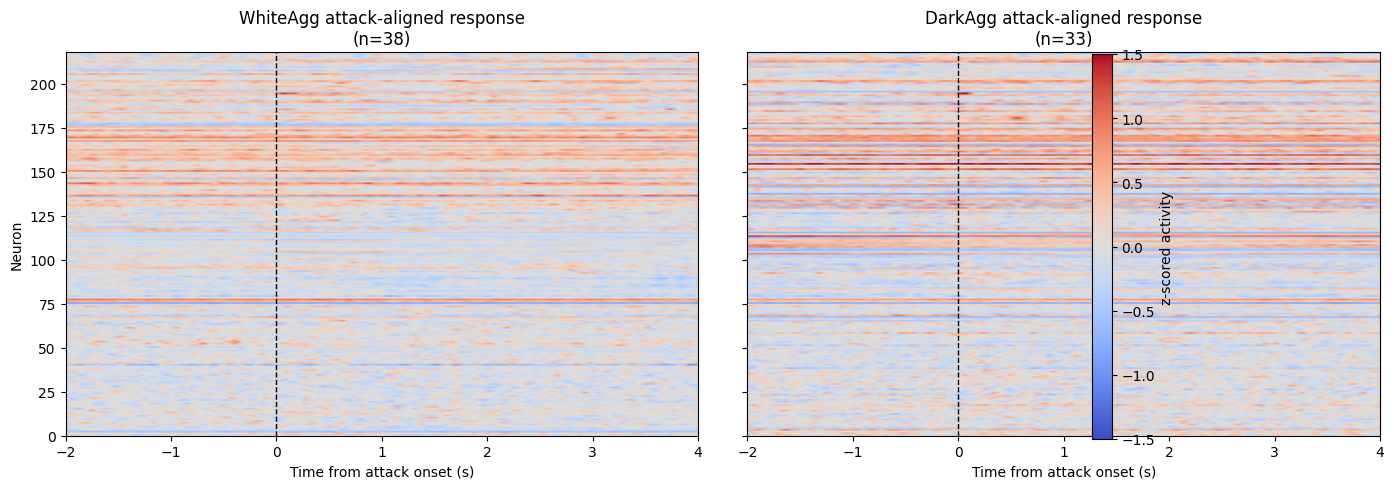

In [21]:
white_avg_by_neuron = white_windows.mean(axis=0) if len(white_windows) > 0 else None   # neurons x time
dark_avg_by_neuron = dark_windows.mean(axis=0) if len(dark_windows) > 0 else None

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

if white_avg_by_neuron is not None:
    im0 = axes[0].imshow(
        white_avg_by_neuron,
        aspect="auto",
        origin="lower",
        extent=[time_event[0], time_event[-1], 0, white_avg_by_neuron.shape[0]],
        cmap="coolwarm",
        vmin=-1.5, vmax=1.5
    )
    axes[0].axvline(0, color="k", linestyle="--", lw=1)
    axes[0].set_title(f"WhiteAgg attack-aligned response\n(n={len(white_windows)})")
    axes[0].set_xlabel("Time from attack onset (s)")
    axes[0].set_ylabel("Neuron")

if dark_avg_by_neuron is not None:
    im1 = axes[1].imshow(
        dark_avg_by_neuron,
        aspect="auto",
        origin="lower",
        extent=[time_event[0], time_event[-1], 0, dark_avg_by_neuron.shape[0]],
        cmap="coolwarm",
        vmin=-1.5, vmax=1.5
    )
    axes[1].axvline(0, color="k", linestyle="--", lw=1)
    axes[1].set_title(f"DarkAgg attack-aligned response\n(n={len(dark_windows)})")
    axes[1].set_xlabel("Time from attack onset (s)")

plt.colorbar(im0 if white_avg_by_neuron is not None else im1, ax=axes.ravel().tolist(), label="z-scored activity")
plt.tight_layout()
plt.show()

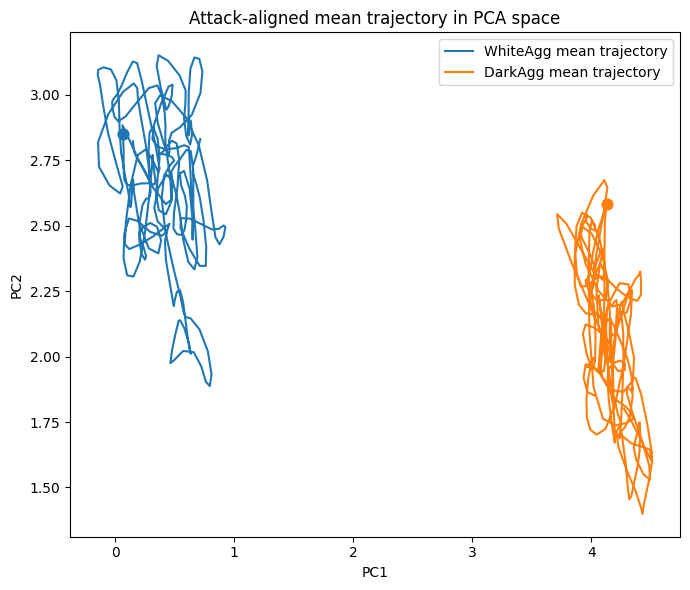

In [22]:
# X_pca 是你第一步已经算出来的：shape = (nT, 3) 或更多
# 这里直接从已有 PCA 空间中取窗口

def extract_pca_windows(X_pca, onsets, pre_bins, post_bins):
    windows = []
    for o in onsets:
        w = X_pca[o - pre_bins : o + post_bins + 1, :]
        windows.append(w)
    if len(windows) == 0:
        return np.empty((0, pre_bins + post_bins + 1, X_pca.shape[1]))
    return np.stack(windows, axis=0)

white_pca_windows = extract_pca_windows(X_pca, white_attack_onsets, pre_bins, post_bins)
dark_pca_windows = extract_pca_windows(X_pca, dark_attack_onsets, pre_bins, post_bins)

white_pca_mean = white_pca_windows.mean(axis=0) if len(white_pca_windows) > 0 else None   # time x pcs
dark_pca_mean = dark_pca_windows.mean(axis=0) if len(dark_pca_windows) > 0 else None

fig, ax = plt.subplots(figsize=(7, 6))

if white_pca_mean is not None:
    ax.plot(white_pca_mean[:, 0], white_pca_mean[:, 1], label="WhiteAgg mean trajectory")
    ax.scatter(white_pca_mean[pre_bins, 0], white_pca_mean[pre_bins, 1], s=60, marker="o")  # onset

if dark_pca_mean is not None:
    ax.plot(dark_pca_mean[:, 0], dark_pca_mean[:, 1], label="DarkAgg mean trajectory")
    ax.scatter(dark_pca_mean[pre_bins, 0], dark_pca_mean[pre_bins, 1], s=60, marker="o")  # onset

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Attack-aligned mean trajectory in PCA space")
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
def pre_post_response_index(windows, pre_bins, post_bins, post_start_sec=0.0, post_end_sec=1.0):
    """
    windows: (n_events, n_neurons, n_time)
    Compute event-level response index:
        mean(post window) - mean(pre window)
    after averaging over neurons.
    """
    if len(windows) == 0:
        return np.array([])

    pre_slice = slice(0, pre_bins)  # onset 前
    post_slice = slice(pre_bins + int(post_start_sec * fs), pre_bins + int(post_end_sec * fs))

    event_curves = windows.mean(axis=1)   # (n_events, n_time)
    pre_vals = event_curves[:, pre_slice].mean(axis=1)
    post_vals = event_curves[:, post_slice].mean(axis=1)

    return post_vals - pre_vals

white_resp_idx = pre_post_response_index(white_windows, pre_bins, post_bins, post_start_sec=0.0, post_end_sec=1.0)
dark_resp_idx = pre_post_response_index(dark_windows, pre_bins, post_bins, post_start_sec=0.0, post_end_sec=1.0)

print("White response index:", white_resp_idx)
print("Dark response index :", dark_resp_idx)
print("White mean ± std:", np.mean(white_resp_idx) if len(white_resp_idx) else None,
      np.std(white_resp_idx) if len(white_resp_idx) else None)
print("Dark mean ± std :", np.mean(dark_resp_idx) if len(dark_resp_idx) else None,
      np.std(dark_resp_idx) if len(dark_resp_idx) else None)

White response index: [-0.11376782  0.07748501  0.06393995  0.04100967 -0.05044923 -0.02795087
  0.07728447 -0.10240255 -0.04106    -0.04497883 -0.02853131  0.131527
  0.09916262 -0.04862612  0.03223749 -0.03079226  0.07743664 -0.01567437
 -0.01381865  0.0015177  -0.01399851  0.13518216 -0.14784835  0.16167773
 -0.02752017 -0.08434955  0.02373488 -0.17399359 -0.19780917  0.02431452
  0.03654225  0.0850564  -0.06062741  0.06948469  0.02269461  0.01738817
 -0.00655581  0.18113184]
Dark response index : [ 0.05196727 -0.0654289  -0.03273696  0.0715861   0.06799927  0.05480115
 -0.02436374 -0.09200752  0.03671074  0.00062057 -0.03817066  0.03544858
  0.08110726 -0.05840484  0.0381178   0.03323713  0.1192851  -0.16232931
 -0.00817583 -0.00528036  0.09587661 -0.10094712  0.04559991 -0.08083776
  0.02257595  0.11496096  0.02518222  0.35065959  0.02418479  0.06559655
 -0.09881761  0.19318893  0.14127518]
White mean ± std: 0.0033698231419736447 0.08616919493879276
Dark mean ± std : 0.02734791176

In [24]:
# Per-neuron response index: mean(post) - mean(pre)
def per_neuron_response_index(avg_by_neuron, pre_bins, fs, post_start_sec=0.0, post_end_sec=1.0):
    """
    avg_by_neuron: (n_neurons, n_time)
    returns: (n_neurons,)
    """
    pre_slice = slice(0, pre_bins)
    post_slice = slice(pre_bins + int(post_start_sec * fs),
                       pre_bins + int(post_end_sec * fs))
    pre_vals = avg_by_neuron[:, pre_slice].mean(axis=1)
    post_vals = avg_by_neuron[:, post_slice].mean(axis=1)
    return post_vals - pre_vals

white_neuron_idx = per_neuron_response_index(white_avg_by_neuron, pre_bins, fs)
dark_neuron_idx  = per_neuron_response_index(dark_avg_by_neuron,  pre_bins, fs)

print("White neuron index:", white_neuron_idx.shape)
print("Dark neuron index :", dark_neuron_idx.shape)

White neuron index: (218,)
Dark neuron index : (218,)


/var/folders/r5/mxyjzgdn5cdfskhnwphlz_580000gn/T/ipykernel_34213/2656810447.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


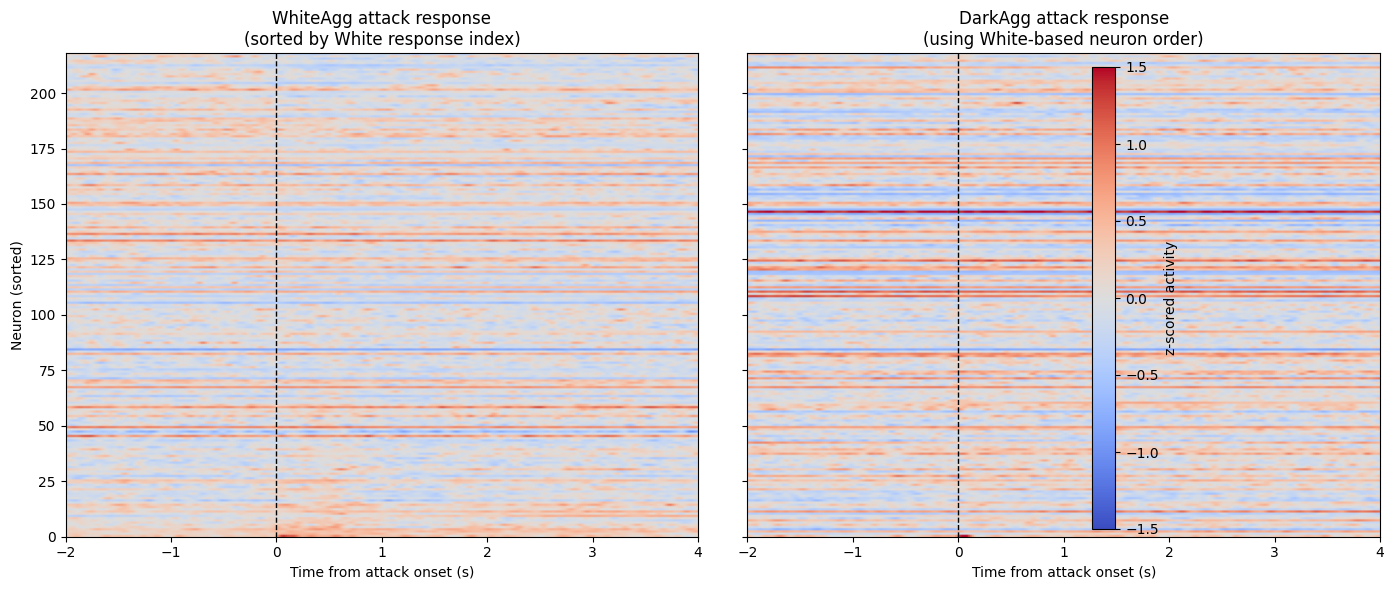

In [25]:
sort_idx_white = np.argsort(white_neuron_idx)[::-1]  # descending

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

im0 = axes[0].imshow(
    white_avg_by_neuron[sort_idx_white],
    aspect="auto",
    origin="lower",
    extent=[time_event[0], time_event[-1], 0, white_avg_by_neuron.shape[0]],
    cmap="coolwarm",
    vmin=-1.5, vmax=1.5
)
axes[0].axvline(0, color="k", linestyle="--", lw=1)
axes[0].set_title("WhiteAgg attack response\n(sorted by White response index)")
axes[0].set_xlabel("Time from attack onset (s)")
axes[0].set_ylabel("Neuron (sorted)")

im1 = axes[1].imshow(
    dark_avg_by_neuron[sort_idx_white],
    aspect="auto",
    origin="lower",
    extent=[time_event[0], time_event[-1], 0, dark_avg_by_neuron.shape[0]],
    cmap="coolwarm",
    vmin=-1.5, vmax=1.5
)
axes[1].axvline(0, color="k", linestyle="--", lw=1)
axes[1].set_title("DarkAgg attack response\n(using White-based neuron order)")
axes[1].set_xlabel("Time from attack onset (s)")

fig.colorbar(im0, ax=axes.ravel().tolist(), label="z-scored activity")
plt.tight_layout()
plt.show()

/var/folders/r5/mxyjzgdn5cdfskhnwphlz_580000gn/T/ipykernel_34213/1162996932.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


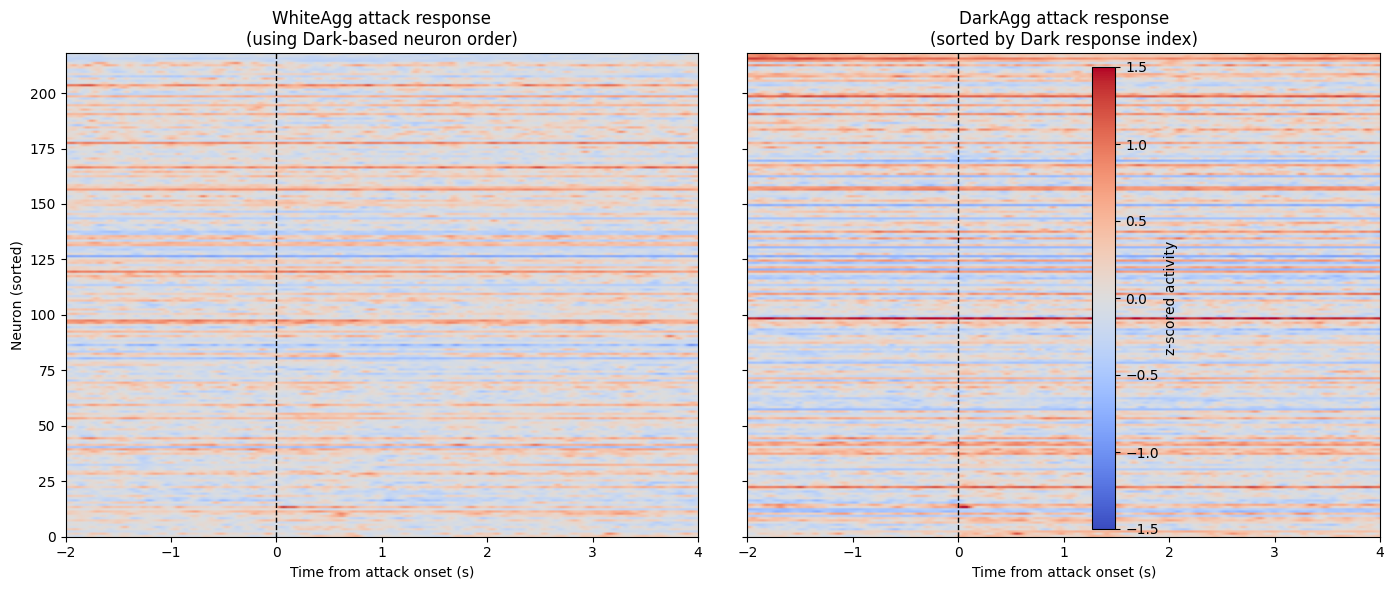

In [26]:
sort_idx_dark = np.argsort(dark_neuron_idx)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

im0 = axes[0].imshow(
    white_avg_by_neuron[sort_idx_dark],
    aspect="auto",
    origin="lower",
    extent=[time_event[0], time_event[-1], 0, white_avg_by_neuron.shape[0]],
    cmap="coolwarm",
    vmin=-1.5, vmax=1.5
)
axes[0].axvline(0, color="k", linestyle="--", lw=1)
axes[0].set_title("WhiteAgg attack response\n(using Dark-based neuron order)")
axes[0].set_xlabel("Time from attack onset (s)")
axes[0].set_ylabel("Neuron (sorted)")

im1 = axes[1].imshow(
    dark_avg_by_neuron[sort_idx_dark],
    aspect="auto",
    origin="lower",
    extent=[time_event[0], time_event[-1], 0, dark_avg_by_neuron.shape[0]],
    cmap="coolwarm",
    vmin=-1.5, vmax=1.5
)
axes[1].axvline(0, color="k", linestyle="--", lw=1)
axes[1].set_title("DarkAgg attack response\n(sorted by Dark response index)")
axes[1].set_xlabel("Time from attack onset (s)")

fig.colorbar(im1, ax=axes.ravel().tolist(), label="z-scored activity")
plt.tight_layout()
plt.show()

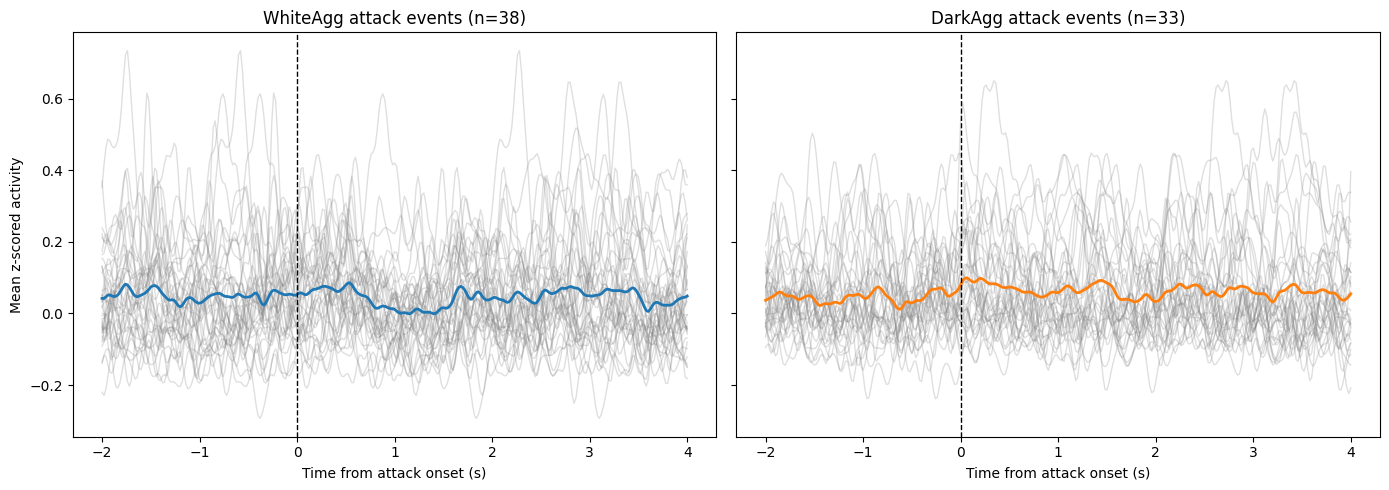

In [27]:
def event_population_curves(windows):
    # windows: (n_events, n_neurons, n_time)
    return windows.mean(axis=1)  # (n_events, n_time)

white_event_curves = event_population_curves(white_windows)
dark_event_curves  = event_population_curves(dark_windows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i in range(white_event_curves.shape[0]):
    axes[0].plot(time_event, white_event_curves[i], color="gray", alpha=0.25, lw=1)
axes[0].plot(time_event, white_event_curves.mean(axis=0), color="tab:blue", lw=2)
axes[0].axvline(0, color="k", linestyle="--", lw=1)
axes[0].set_title(f"WhiteAgg attack events (n={white_event_curves.shape[0]})")
axes[0].set_xlabel("Time from attack onset (s)")
axes[0].set_ylabel("Mean z-scored activity")

for i in range(dark_event_curves.shape[0]):
    axes[1].plot(time_event, dark_event_curves[i], color="gray", alpha=0.25, lw=1)
axes[1].plot(time_event, dark_event_curves.mean(axis=0), color="tab:orange", lw=2)
axes[1].axvline(0, color="k", linestyle="--", lw=1)
axes[1].set_title(f"DarkAgg attack events (n={dark_event_curves.shape[0]})")
axes[1].set_xlabel("Time from attack onset (s)")

plt.tight_layout()
plt.show()

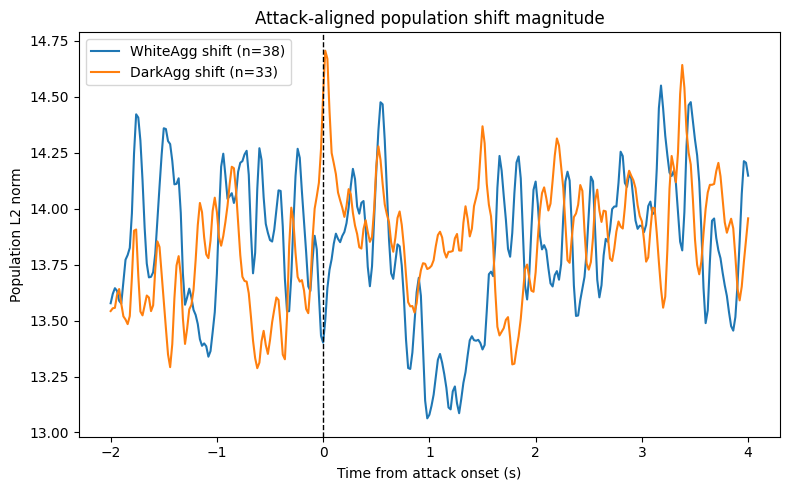

In [28]:
def population_shift_magnitude(windows):
    """
    windows: (n_events, n_neurons, n_time)
    For each event and each time point, compute L2 norm across neurons.
    """
    return np.linalg.norm(windows, axis=1)  # (n_events, n_time)

white_shift = population_shift_magnitude(white_windows)
dark_shift  = population_shift_magnitude(dark_windows)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(time_event, white_shift.mean(axis=0), label=f"WhiteAgg shift (n={len(white_shift)})")
ax.plot(time_event, dark_shift.mean(axis=0), label=f"DarkAgg shift (n={len(dark_shift)})")

ax.axvline(0, color="k", linestyle="--", lw=1)
ax.set_xlabel("Time from attack onset (s)")
ax.set_ylabel("Population L2 norm")
ax.set_title("Attack-aligned population shift magnitude")
ax.legend()
plt.tight_layout()
plt.show()